In [1]:
import pandas as pd

In [2]:
df = pd.read_excel("Dataset for Data Analytics.xlsx")

In [3]:
df.head()

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04


In [4]:
df.shape

(1200, 14)

In [5]:
df.columns

Index(['OrderID', 'Date', 'CustomerID', 'Product', 'Quantity', 'UnitPrice',
       'ShippingAddress', 'PaymentMethod', 'OrderStatus', 'TrackingNumber',
       'ItemsInCart', 'CouponCode', 'ReferralSource', 'TotalPrice'],
      dtype='str')

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   OrderID          1200 non-null   str           
 1   Date             1200 non-null   datetime64[us]
 2   CustomerID       1200 non-null   str           
 3   Product          1200 non-null   str           
 4   Quantity         1200 non-null   int64         
 5   UnitPrice        1200 non-null   float64       
 6   ShippingAddress  1200 non-null   str           
 7   PaymentMethod    1200 non-null   str           
 8   OrderStatus      1200 non-null   str           
 9   TrackingNumber   1200 non-null   str           
 10  ItemsInCart      1200 non-null   int64         
 11  CouponCode       891 non-null    str           
 12  ReferralSource   1200 non-null   str           
 13  TotalPrice       1200 non-null   float64       
dtypes: datetime64[us](1), float64(2), int64(2), str(9)


In [7]:
df.describe()

,Date,Quantity,UnitPrice,ItemsInCart,TotalPrice
count,1200,1200.000000,1200.000000,1200.000000,1200.000000
mean,2024-03-22 16:58:48,2.945833,356.412750,5.485000,1053.968300
min,2023-01-01 00:00:00,1.000000,11.390000,1.000000,11.390000
25%,2023-08-03 18:00:00,2.000000,186.062500,4.000000,410.520000
50%,2024-03-23 00:00:00,3.000000,364.210000,5.000000,823.615000
75%,2024-11-08 12:00:00,4.000000,521.570000,7.000000,1578.475000
max,2025-06-30 00:00:00,5.000000,699.930000,10.000000,3456.400000
std,NaN,1.407557,197.177146,2.281983,819.856558


In [8]:
df.isnull().sum()

OrderID              0
Date                 0
CustomerID           0
Product              0
Quantity             0
UnitPrice            0
ShippingAddress      0
PaymentMethod        0
OrderStatus          0
TrackingNumber       0
ItemsInCart          0
CouponCode         309
ReferralSource       0
TotalPrice           0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df = df.drop_duplicates()

In [11]:
df.shape

(1200, 14)

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

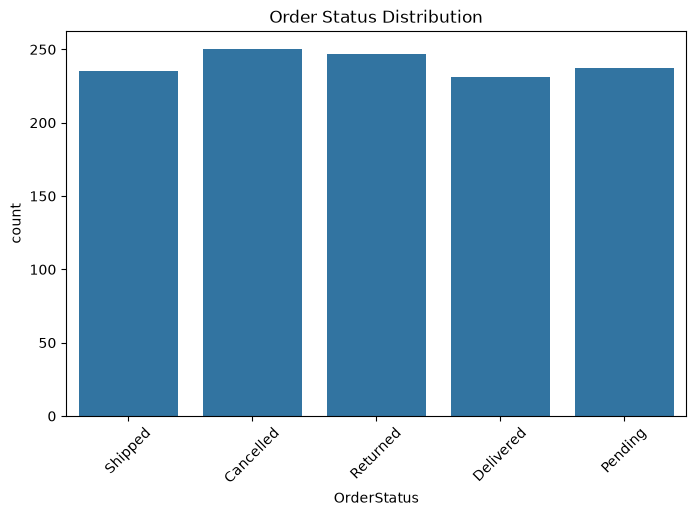

In [13]:
plt.figure(figsize=(8,5))
sns.countplot(x="OrderStatus", data=df)
plt.title("Order Status Distribution")
plt.xticks(rotation=45)
plt.show()

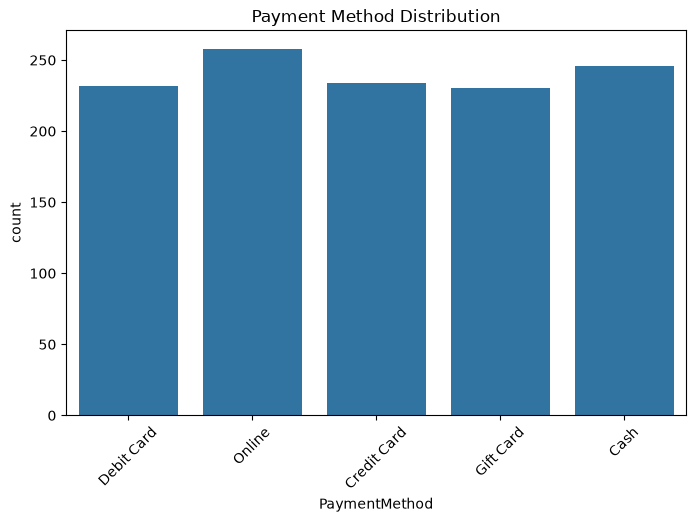

In [14]:
plt.figure(figsize=(8,5))
sns.countplot(x="PaymentMethod", data=df)
plt.title("Payment Method Distribution")
plt.xticks(rotation=45)
plt.show()

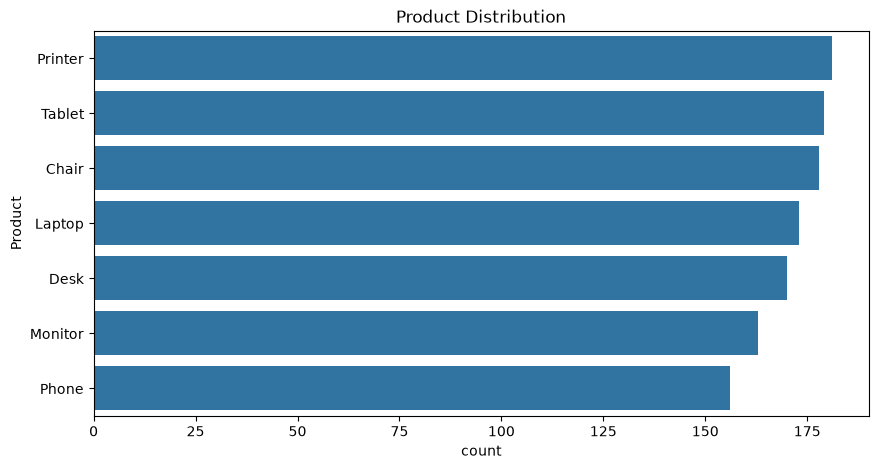

In [15]:
plt.figure(figsize=(10,5))
sns.countplot(
    y="Product",
    data=df,
    order=df["Product"].value_counts().index
)
plt.title("Product Distribution")
plt.show()

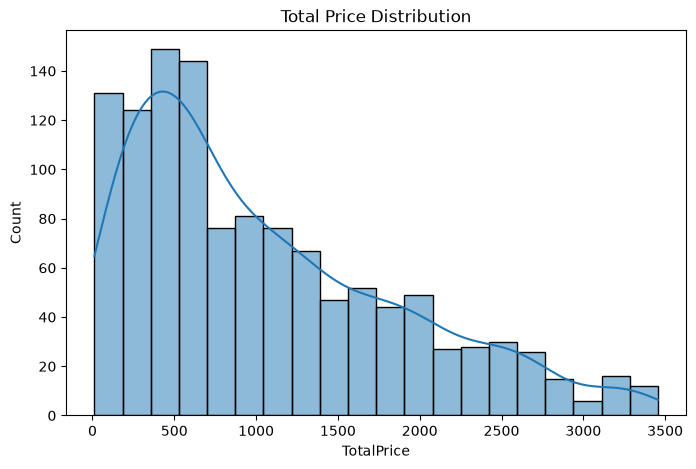

In [16]:
plt.figure(figsize=(8,5))
sns.histplot(df["TotalPrice"], bins=20, kde=True)
plt.title("Total Price Distribution")
plt.show()

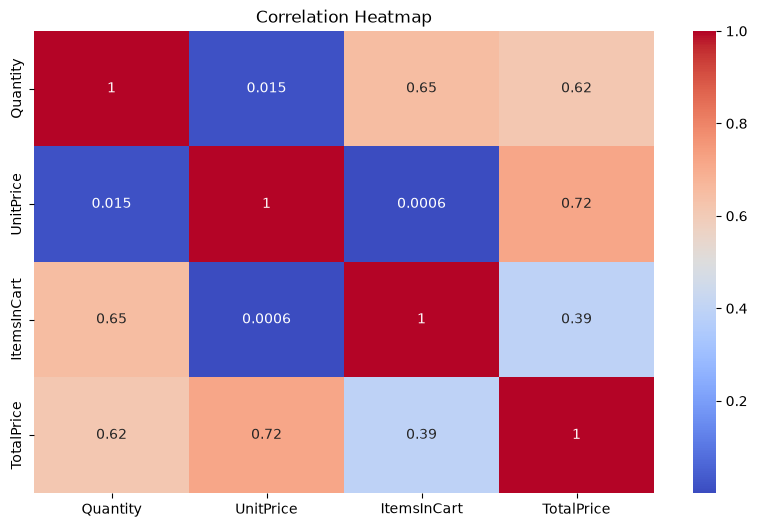

In [17]:
plt.figure(figsize=(10,6))

numeric_df = df.select_dtypes(include="number")

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")
plt.show()

In [18]:
df["Fraud"] = 0

df.loc[
    (df["TotalPrice"] > 2500) &
    (df["Quantity"] >= 5) &
    (df["ItemsInCart"] >= 5),
    "Fraud"
] = 1

df.head()

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice,Fraud
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10,1
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70,0
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40,1
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19,0
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04,0


In [19]:
df["Fraud"].value_counts()

Fraud
0    1138
1      62
Name: count, dtype: int64

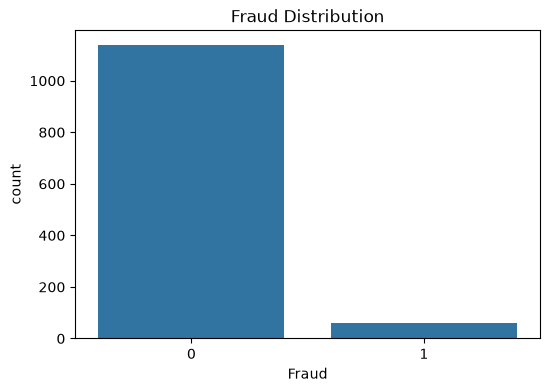

In [20]:
plt.figure(figsize=(6,4))
sns.countplot(x="Fraud", data=df)

plt.title("Fraud Distribution")
plt.show()

In [22]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

for col in df.select_dtypes(include=["object", "string"]).columns:
    df[col] = encoder.fit_transform(df[col].astype(str))

df.head()

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice,Fraud
0,0,2023-01-04,856,3,5,570.62,596,2,4,359,7,1,3,2853.10,1
1,1,2024-08-23,888,4,2,151.35,512,4,4,1074,3,1,4,302.70,0
2,2,2024-02-27,950,6,5,550.68,294,1,0,416,8,0,0,2753.40,1
3,3,2023-10-15,332,0,1,273.19,124,2,3,691,5,1,1,273.19,0
4,4,2025-05-08,951,5,4,626.01,407,4,1,245,8,1,0,2504.04,0


In [29]:

if "Date" in X.columns:
    X["Date"] = pd.to_datetime(X["Date"])
    X["Date"] = X["Date"].map(pd.Timestamp.toordinal)

print(X.dtypes)

OrderID              int64
Date                 int64
CustomerID           int64
Product              int64
Quantity             int64
UnitPrice          float64
ShippingAddress      int64
PaymentMethod        int64
OrderStatus          int64
TrackingNumber       int64
ItemsInCart          int64
CouponCode           int64
ReferralSource       int64
TotalPrice         float64
dtype: object


In [32]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(960, 14)
(240, 14)


In [33]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

print("Before SMOTE")
print(y_train.value_counts())

print("\nAfter SMOTE")
print(y_train_smote.value_counts())

Before SMOTE
Fraud
0    910
1     50
Name: count, dtype: int64

After SMOTE
Fraud
0    910
1    910
Name: count, dtype: int64


In [34]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

lr_model.fit(X_train_smote, y_train_smote)

print("Logistic Regression Model Trained Successfully!")

Logistic Regression Model Trained Successfully!


In [35]:
y_pred_lr = lr_model.predict(X_test)

print(y_pred_lr[:10])

[0 0 0 0 0 0 0 0 1 0]


In [36]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       228
           1       1.00      1.00      1.00        12

    accuracy                           1.00       240
   macro avg       1.00      1.00      1.00       240
weighted avg       1.00      1.00      1.00       240



In [37]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_lr)

print(cm)

[[228   0]
 [  0  12]]


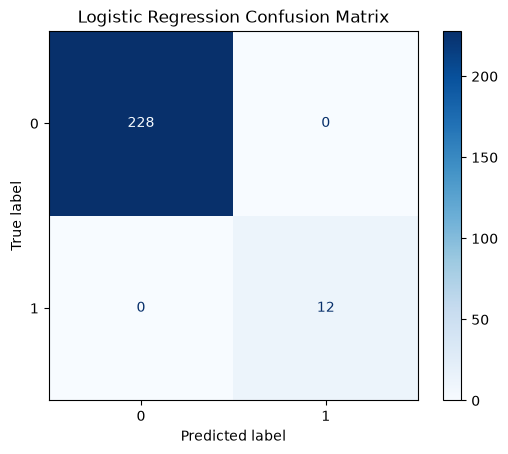

In [38]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot(cmap="Blues")

plt.title("Logistic Regression Confusion Matrix")

plt.show()

In [39]:
from sklearn.metrics import roc_auc_score

y_prob = lr_model.predict_proba(X_test)[:, 1]

roc = roc_auc_score(y_test, y_prob)

print("ROC-AUC Score:", roc)

ROC-AUC Score: 1.0


In [40]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train_smote, y_train_smote)

print("Random Forest Trained Successfully!")

Random Forest Trained Successfully!


In [41]:
y_pred_rf = rf_model.predict(X_test)

print(y_pred_rf[:10])

[0 0 0 0 0 0 0 0 1 0]


In [42]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       228
           1       1.00      1.00      1.00        12

    accuracy                           1.00       240
   macro avg       1.00      1.00      1.00       240
weighted avg       1.00      1.00      1.00       240



In [43]:
from sklearn.metrics import confusion_matrix

cm_rf = confusion_matrix(y_test, y_pred_rf)

print(cm_rf)

[[228   0]
 [  0  12]]


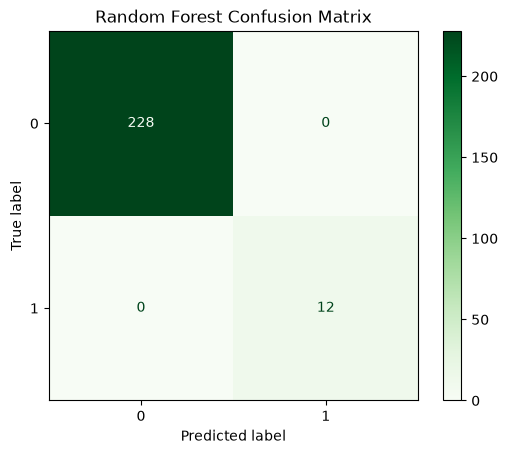

In [44]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

disp = ConfusionMatrixDisplay(confusion_matrix=cm_rf)

disp.plot(cmap="Greens")

plt.title("Random Forest Confusion Matrix")

plt.show()

In [45]:
from sklearn.metrics import roc_auc_score

y_prob_rf = rf_model.predict_proba(X_test)[:,1]

roc_rf = roc_auc_score(y_test, y_prob_rf)

print("Random Forest ROC-AUC:", roc_rf)

Random Forest ROC-AUC: 1.0


In [46]:
from sklearn.model_selection import GridSearchCV

params = {
    "n_estimators":[100,200],
    "max_depth":[5,10,None],
    "min_samples_split":[2,5]
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    params,
    cv=3,
    scoring="recall",
    n_jobs=-1
)

grid.fit(X_train_smote, y_train_smote)

print("Best Parameters:")
print(grid.best_params_)

Best Parameters:
{'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 100}


In [47]:
best_rf = grid.best_estimator_

best_rf.fit(X_train_smote, y_train_smote)

print("Best Random Forest Model Ready!")

Best Random Forest Model Ready!


In [48]:
best_pred = best_rf.predict(X_test)

print(classification_report(y_test, best_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       228
           1       1.00      1.00      1.00        12

    accuracy                           1.00       240
   macro avg       1.00      1.00      1.00       240
weighted avg       1.00      1.00      1.00       240



In [49]:
comparison = {
    "Model":["Logistic Regression","Random Forest"],
    "ROC-AUC":[roc, roc_rf]
}

import pandas as pd

comparison_df = pd.DataFrame(comparison)

comparison_df

,Model,ROC-AUC
0,Logistic Regression,1.0
1,Random Forest,1.0


In [50]:
if roc_rf > roc:
    print("Random Forest performed better than Logistic Regression.")
else:
    print("Logistic Regression performed better than Random Forest.")

Logistic Regression performed better than Random Forest.
